# Notebook 04: SHAP Interpretability Analysis
## Wearable-Enhanced Insurance Underwriting — NHANES 2003-2004

**Author:** Lubaba Hassan | 22097014D | PolyU Data Science and Analytics

This notebook uses SHAP (SHapley Additive exPlanations) to interpret the trained classifiers
and answer **RQ3** regarding interpretability:

1. Global feature importance rankings (Scenario A vs B)
2. SHAP summary plots showing feature-prediction relationships
3. Per-class SHAP analysis (what drives Low vs Intermediate vs High)
4. Individual prediction explanations (waterfall plots)
5. Wearable feature contribution analysis (Scenario A vs B comparison)

**Key question:** How do wearable features contribute to predictions compared to traditional features?

## 1. Imports and Setup

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

DATA_PATH = '../data/processed/'
FIGURES_PATH = '../reports/figures/'
RANDOM_STATE = 42
TEST_SIZE = 0.2

LABEL_COL = 'risk_class'
LABEL_NAMES = {0: 'Low', 1: 'Intermediate', 2: 'High'}
CLASS_ORDER = ['Low', 'Intermediate', 'High']

# Initialize SHAP
shap.initjs()
print('All imports successful.')
print(f'SHAP version: {shap.__version__}')

All imports successful.
SHAP version: 0.51.0


## 2. Load Data and Retrain Best Models

In [9]:
scenario_a = pd.read_csv(DATA_PATH + 'scenario_a.csv')
scenario_b = pd.read_csv(DATA_PATH + 'scenario_b.csv')

TRADITIONAL_FEATURES = [
    'age', 'male', 'bmi', 'waist_cm',
    'systolic_bp', 'diastolic_bp',
    'total_cholesterol', 'hdl_cholesterol',
    'ever_smoker', 'self_rated_health',
    'daily_activity_level', 'high_chol_told',
    'bp_hypertension_measured'
]
WEARABLE_FEATURES = [
    'total_met_hours', 'mean_met', 'total_activities',
    'moderate_count', 'vigorous_count', 'vigorous_ratio',
    'activity_category'
]

FEATURES_A = TRADITIONAL_FEATURES
FEATURES_B = TRADITIONAL_FEATURES + WEARABLE_FEATURES

print(f'Scenario A: {scenario_a.shape[0]:,} participants, {len(FEATURES_A)} features')
print(f'Scenario B: {scenario_b.shape[0]:,} participants, {len(FEATURES_B)} features')

Scenario A: 3,388 participants, 13 features
Scenario B: 1,887 participants, 20 features


In [10]:
# Train XGBoost on Scenario A
X_a = scenario_a[FEATURES_A].values
y_a = scenario_a[LABEL_COL].values.astype(int)
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_a)
sw_a = compute_sample_weight('balanced', y_a_train)

xgb_a = XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1,
    n_estimators=200, max_depth=5, learning_rate=0.1, subsample=0.8)
xgb_a.fit(X_a_train, y_a_train, sample_weight=sw_a)
print(f'XGBoost Scenario A trained. Test accuracy: {xgb_a.score(X_a_test, y_a_test):.4f}')

# Train XGBoost on Scenario B
X_b = scenario_b[FEATURES_B].values
y_b = scenario_b[LABEL_COL].values.astype(int)
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b, y_b, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_b)
sw_b = compute_sample_weight('balanced', y_b_train)

xgb_b = XGBClassifier(
    objective='multi:softprob', num_class=3, eval_metric='mlogloss',
    use_label_encoder=False, random_state=RANDOM_STATE, n_jobs=-1,
    n_estimators=200, max_depth=5, learning_rate=0.1, subsample=0.8)
xgb_b.fit(X_b_train, y_b_train, sample_weight=sw_b)
print(f'XGBoost Scenario B trained. Test accuracy: {xgb_b.score(X_b_test, y_b_test):.4f}')

# Train Random Forest on Scenario A (for comparison)
rf_a = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1)
rf_a.fit(X_a_train, y_a_train)
print(f'Random Forest Scenario A trained. Test accuracy: {rf_a.score(X_a_test, y_a_test):.4f}')

XGBoost Scenario A trained. Test accuracy: 0.8894
XGBoost Scenario B trained. Test accuracy: 0.9153
Random Forest Scenario A trained. Test accuracy: 0.8643


## 3. Compute SHAP Values

In [11]:
# Compute SHAP values using TreeExplainer (fast for tree-based models)
print('Computing SHAP values for XGBoost Scenario A...')
explainer_a = shap.TreeExplainer(xgb_a)
shap_values_a = explainer_a.shap_values(X_a_test)
print(f'  Shape: {np.array(shap_values_a).shape}')
print(f'  (n_classes x n_samples x n_features)')

print('\nComputing SHAP values for XGBoost Scenario B...')
explainer_b = shap.TreeExplainer(xgb_b)
shap_values_b = explainer_b.shap_values(X_b_test)
print(f'  Shape: {np.array(shap_values_b).shape}')

print('\nComputing SHAP values for Random Forest Scenario A...')
explainer_rf = shap.TreeExplainer(rf_a)
shap_values_rf = explainer_rf.shap_values(X_a_test)
print(f'  Shape: {np.array(shap_values_rf).shape}')

print('\nSHAP values computed successfully.')

Computing SHAP values for XGBoost Scenario A...
  Shape: (678, 13, 3)
  (n_classes x n_samples x n_features)

Computing SHAP values for XGBoost Scenario B...
  Shape: (378, 20, 3)

Computing SHAP values for Random Forest Scenario A...
  Shape: (678, 13, 3)

SHAP values computed successfully.


## 4. Global Feature Importance — Scenario A (XGBoost)

GLOBAL FEATURE IMPORTANCE — Scenario A (XGBoost)
  age                            0.8536  ##################################################
  bp_hypertension_measured       0.7444  ###########################################
  male                           0.7129  #########################################
  ever_smoker                    0.4790  ############################
  bmi                            0.4519  ##########################
  systolic_bp                    0.3948  #######################
  hdl_cholesterol                0.2826  ################
  waist_cm                       0.2154  ############
  diastolic_bp                   0.2017  ###########
  total_cholesterol              0.1974  ###########
  self_rated_health              0.1207  #######
  daily_activity_level           0.0706  ####
  high_chol_told                 0.0358  ##


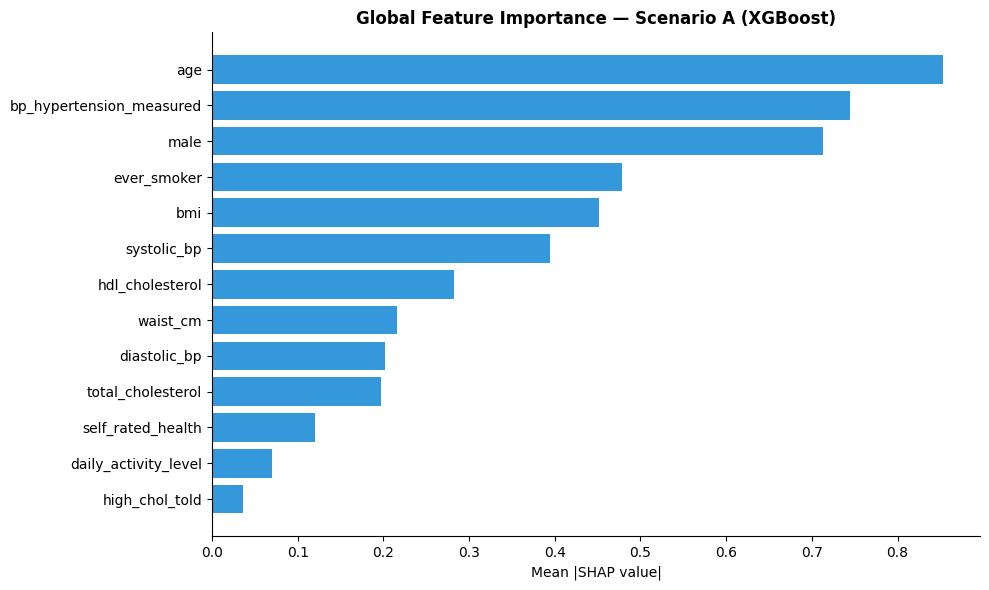

Figure saved.


In [12]:
# SHAP summary plot — all classes combined (Scenario A, XGBoost)
# shap_values_a shape is (n_samples, n_features, n_classes)
# We need mean absolute SHAP across all classes

shap_abs_mean_a = np.mean(np.abs(shap_values_a), axis=2)  # average across 3 classes
feature_importance_a = pd.DataFrame({
    'feature': FEATURES_A,
    'mean_abs_shap': shap_abs_mean_a.mean(axis=0)  # average across samples
}).sort_values('mean_abs_shap', ascending=False)

print('GLOBAL FEATURE IMPORTANCE — Scenario A (XGBoost)')
print('=' * 50)
for _, row in feature_importance_a.iterrows():
    bar = '#' * int(row['mean_abs_shap'] * 50 / feature_importance_a['mean_abs_shap'].max())
    print(f'  {row["feature"]:30s} {row["mean_abs_shap"]:.4f}  {bar}')

# Bar plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_a['feature'][::-1], 
        feature_importance_a['mean_abs_shap'][::-1],
        color='#3498db')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global Feature Importance — Scenario A (XGBoost)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'shap_importance_scenario_a.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

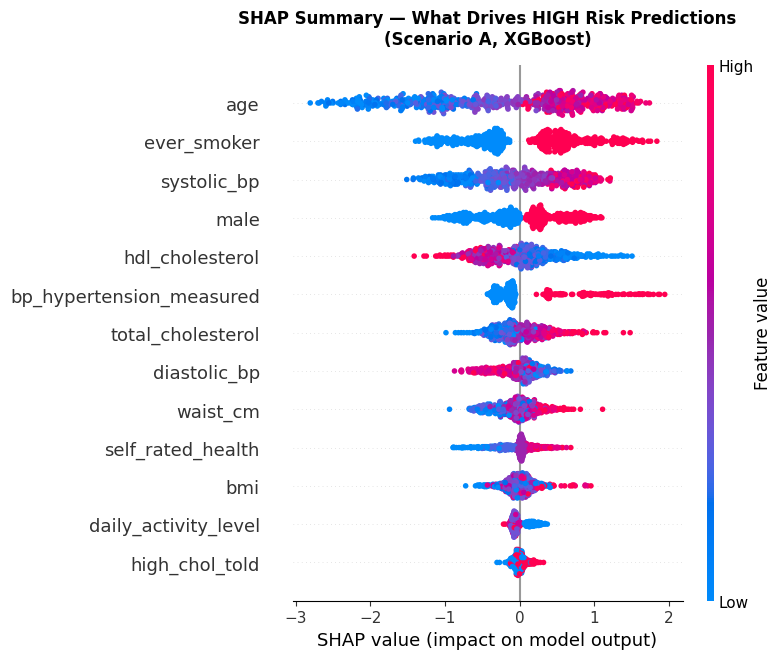

Figure saved.


In [13]:
# SHAP summary beeswarm plot — Scenario A, High risk class
# Shows HOW each feature pushes predictions toward/away from High risk
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values_a[:, :, 2], X_a_test, feature_names=FEATURES_A,
                  show=False, max_display=13)
plt.title('SHAP Summary — What Drives HIGH Risk Predictions\n(Scenario A, XGBoost)',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'shap_summary_high_risk_a.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

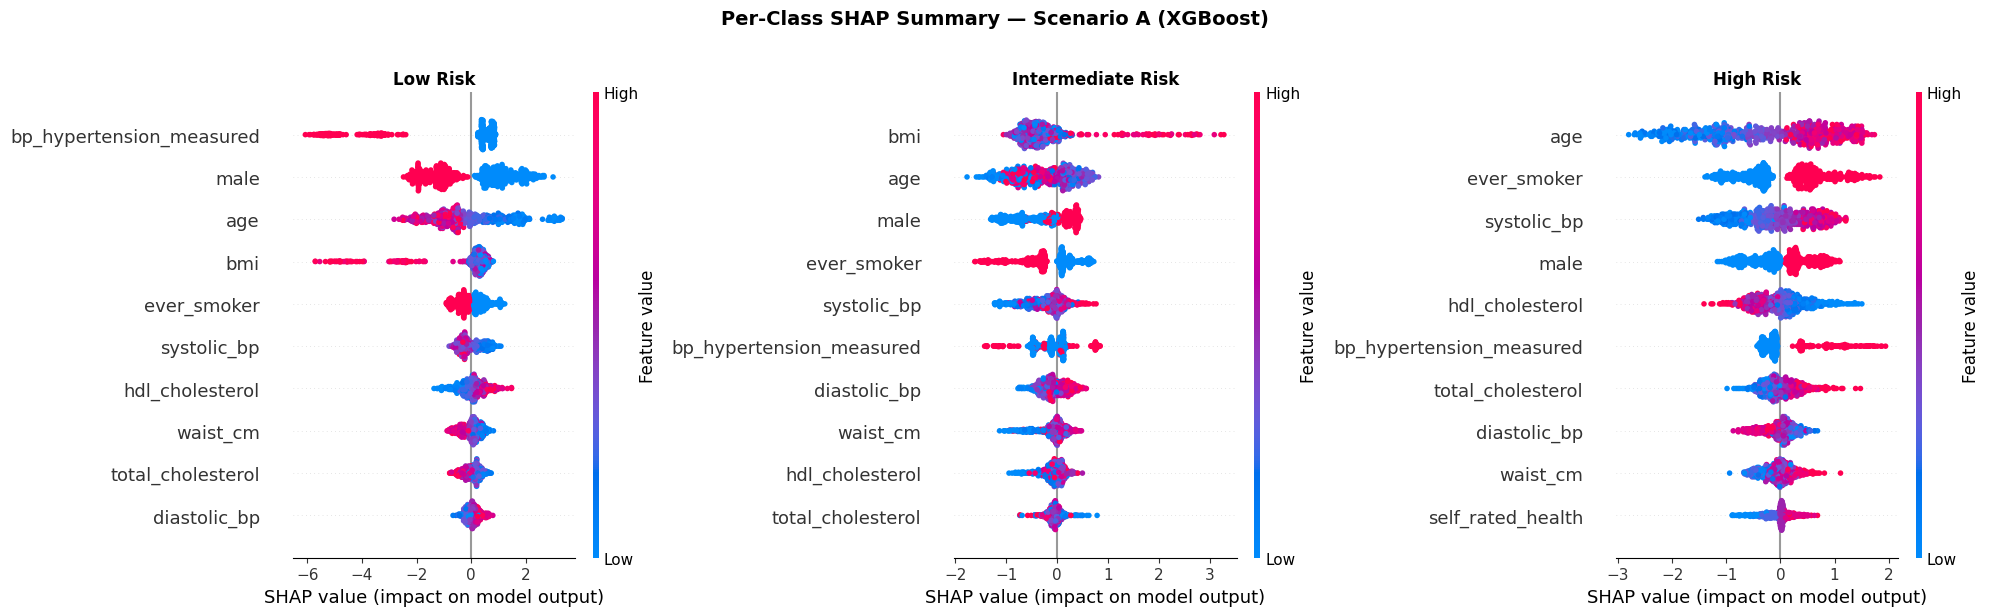

Figure saved.


In [14]:
# SHAP summary for all three classes side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (cls, title) in enumerate([(0, 'Low Risk'), (1, 'Intermediate Risk'), (2, 'High Risk')]):
    plt.sca(axes[idx])
    shap.summary_plot(shap_values_a[:, :, cls], X_a_test, feature_names=FEATURES_A,
                      show=False, max_display=10, plot_size=None)
    axes[idx].set_title(f'{title}', fontweight='bold')

plt.suptitle('Per-Class SHAP Summary — Scenario A (XGBoost)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'shap_per_class_summary_a.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 5. Scenario A vs B — Wearable Feature Contribution

In [15]:
# Global feature importance — Scenario B (XGBoost)
shap_abs_mean_b = np.mean(np.abs(shap_values_b), axis=2)
feature_importance_b = pd.DataFrame({
    'feature': FEATURES_B,
    'mean_abs_shap': shap_abs_mean_b.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

feature_importance_b['type'] = feature_importance_b['feature'].apply(
    lambda x: 'Wearable' if x in WEARABLE_FEATURES else 'Traditional'
)

print('GLOBAL FEATURE IMPORTANCE — Scenario B (XGBoost)')
print('=' * 60)
print(f'{"Rank":>4s}  {"Feature":30s} {"SHAP":>8s} {"Type":>12s}')
print('-' * 60)
for rank, (_, row) in enumerate(feature_importance_b.iterrows(), 1):
    marker = ' ***' if row['type'] == 'Wearable' else ''
    print(f'{rank:>4d}  {row["feature"]:30s} {row["mean_abs_shap"]:>8.4f} {row["type"]:>12s}{marker}')

total_importance = feature_importance_b['mean_abs_shap'].sum()
wearable_importance = feature_importance_b[feature_importance_b['type'] == 'Wearable']['mean_abs_shap'].sum()
print(f'\nWearable features contribute {wearable_importance/total_importance*100:.1f}% of total SHAP importance')

GLOBAL FEATURE IMPORTANCE — Scenario B (XGBoost)
Rank  Feature                            SHAP         Type
------------------------------------------------------------
   1  age                              0.9289  Traditional
   2  male                             0.6783  Traditional
   3  bp_hypertension_measured         0.6340  Traditional
   4  ever_smoker                      0.4434  Traditional
   5  bmi                              0.4314  Traditional
   6  systolic_bp                      0.4136  Traditional
   7  hdl_cholesterol                  0.2838  Traditional
   8  waist_cm                         0.2196  Traditional
   9  total_cholesterol                0.1754  Traditional
  10  diastolic_bp                     0.1663  Traditional
  11  self_rated_health                0.1281  Traditional
  12  mean_met                         0.1107     Wearable ***
  13  total_met_hours                  0.0780     Wearable ***
  14  daily_activity_level             0.0643  Tradition

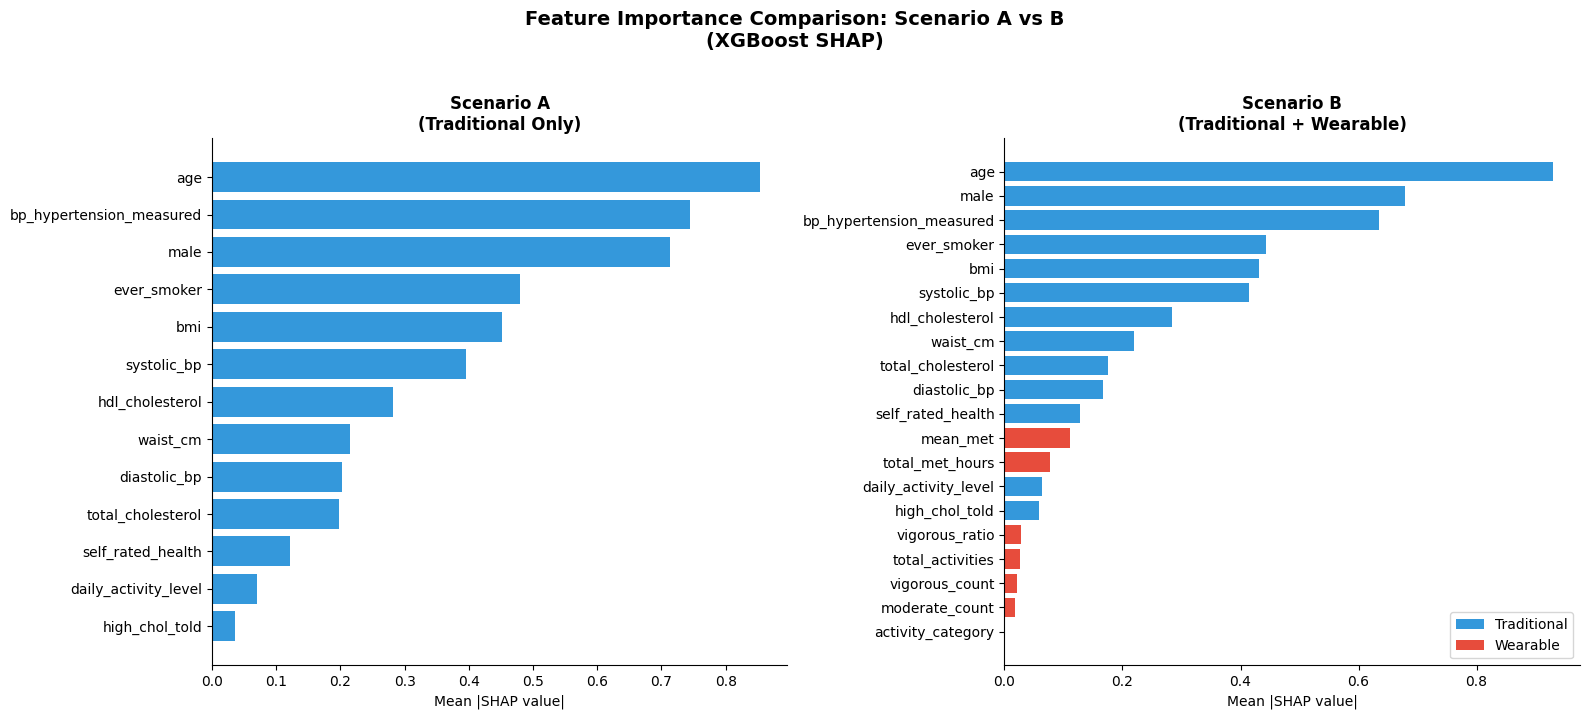

Figure saved.


In [16]:
# Side-by-side importance comparison: Scenario A vs B
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scenario A
ax = axes[0]
fi_a = feature_importance_a.sort_values('mean_abs_shap', ascending=True)
ax.barh(fi_a['feature'], fi_a['mean_abs_shap'], color='#3498db')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Scenario A\n(Traditional Only)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Scenario B
ax = axes[1]
fi_b = feature_importance_b.sort_values('mean_abs_shap', ascending=True)
colors_b = ['#e74c3c' if t == 'Wearable' else '#3498db' for t in fi_b['type']]
ax.barh(fi_b['feature'], fi_b['mean_abs_shap'], color=colors_b)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Scenario B\n(Traditional + Wearable)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add legend for Scenario B
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Traditional'),
                   Patch(facecolor='#e74c3c', label='Wearable')]
axes[1].legend(handles=legend_elements, loc='lower right')

plt.suptitle('Feature Importance Comparison: Scenario A vs B\n(XGBoost SHAP)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'shap_a_vs_b_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

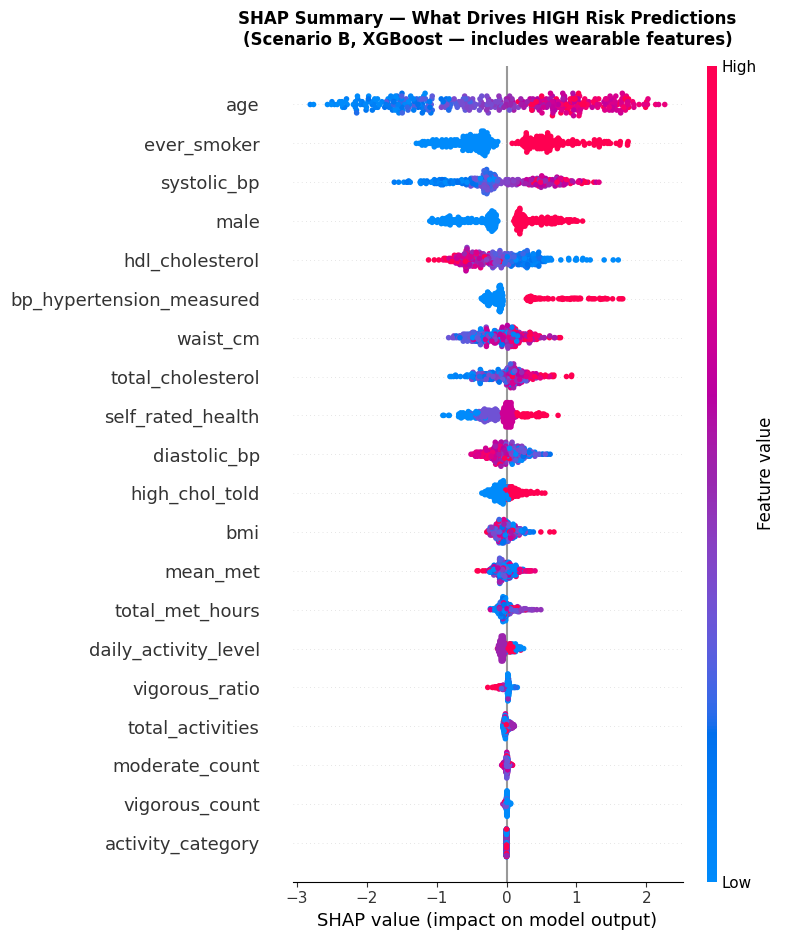

Figure saved.


In [17]:
# SHAP summary beeswarm — Scenario B, High risk class
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values_b[:, :, 2], X_b_test, feature_names=FEATURES_B,
                  show=False, max_display=20)
plt.title('SHAP Summary — What Drives HIGH Risk Predictions\n(Scenario B, XGBoost — includes wearable features)',
          fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'shap_summary_high_risk_b.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 6. Individual Prediction Explanations (Waterfall Plots)

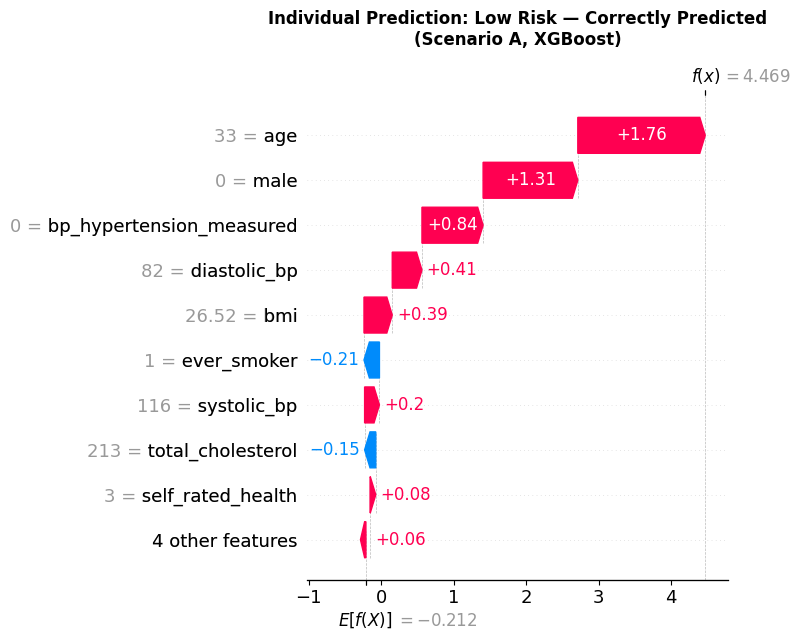

  Low waterfall saved.


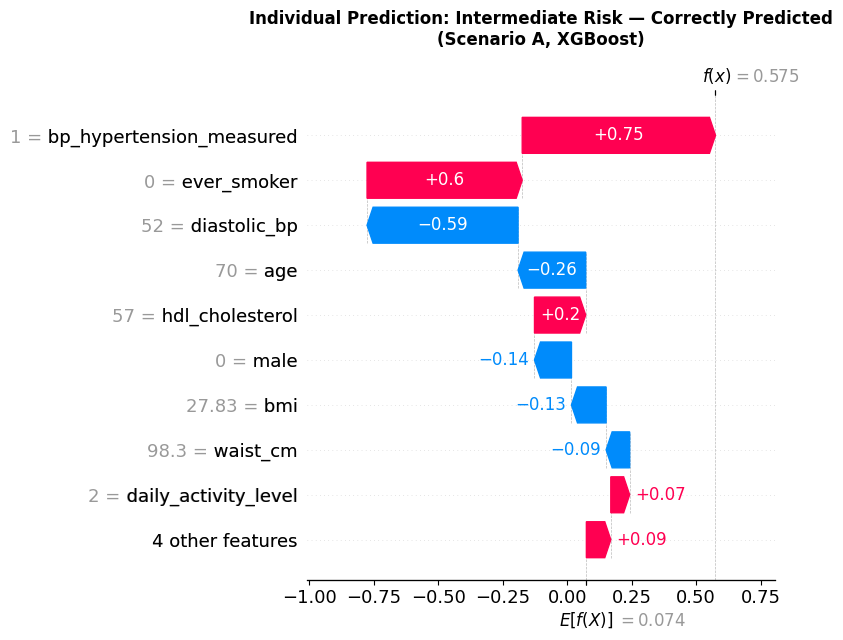

  Intermediate waterfall saved.


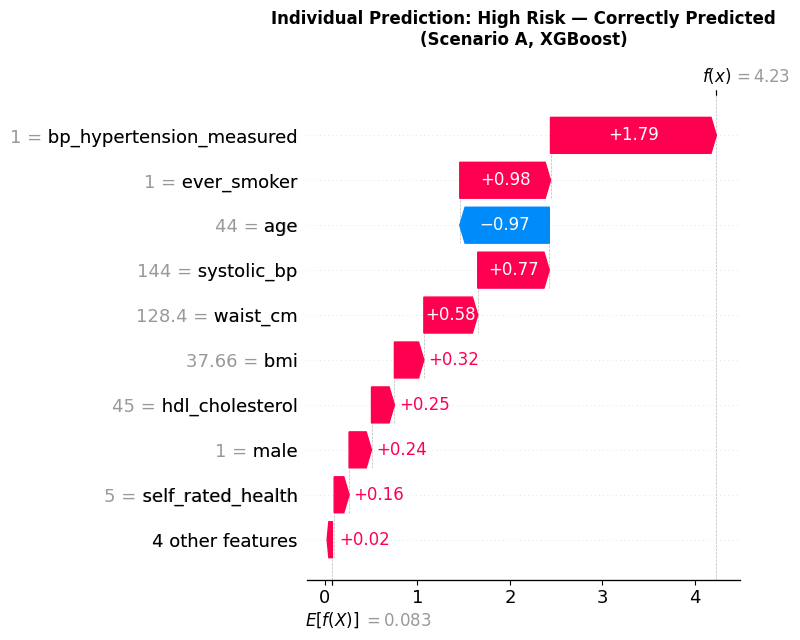

  High waterfall saved.


In [22]:
# Waterfall plots for representative individuals from each class
# Find one correctly predicted example per class
# Waterfall plots — one per class, separate figures for readability
pred_a = xgb_a.predict(X_a_test)

for cls_idx, cls_name in enumerate(CLASS_ORDER):
    correct_mask = (y_a_test == cls_idx) & (pred_a == cls_idx)
    if correct_mask.sum() > 0:
        example_idx = np.where(correct_mask)[0][0]
        
        fig, ax = plt.subplots(figsize=(10, 6))
        plt.sca(ax)
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values_a[example_idx, :, cls_idx],
                base_values=explainer_a.expected_value[cls_idx],
                data=X_a_test[example_idx],
                feature_names=FEATURES_A
            ),
            max_display=10,
            show=False
        )
        plt.title(f'Individual Prediction: {cls_name} Risk — Correctly Predicted\n(Scenario A, XGBoost)',
                  fontweight='bold', fontsize=12, pad=15)
        plt.tight_layout()
        plt.savefig(FIGURES_PATH + f'shap_waterfall_{cls_name.lower()}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  {cls_name} waterfall saved.')

## 7. XGBoost vs Random Forest SHAP Comparison

In [19]:
# Compare feature importance rankings: XGBoost vs Random Forest
shap_abs_mean_rf = np.mean(np.abs(shap_values_rf), axis=2)
fi_rf = pd.DataFrame({
    'feature': FEATURES_A,
    'mean_abs_shap': shap_abs_mean_rf.mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

fi_a_ranked = feature_importance_a.reset_index(drop=True).reset_index()
fi_a_ranked.columns = ['xgb_rank', 'feature', 'xgb_shap']
fi_a_ranked['xgb_rank'] += 1

fi_rf_ranked = fi_rf.reset_index(drop=True).reset_index()
fi_rf_ranked.columns = ['rf_rank', 'feature', 'rf_shap']
fi_rf_ranked['rf_rank'] += 1

comparison = fi_a_ranked.merge(fi_rf_ranked, on='feature')
comparison['rank_diff'] = comparison['rf_rank'] - comparison['xgb_rank']
comparison = comparison.sort_values('xgb_rank')

print('FEATURE IMPORTANCE RANKING: XGBoost vs Random Forest (Scenario A)')
print('=' * 70)
print(f'{"Feature":30s} {"XGB Rank":>10s} {"RF Rank":>10s} {"Diff":>8s}')
print('-' * 70)
for _, row in comparison.iterrows():
    print(f'{row["feature"]:30s} {row["xgb_rank"]:>10.0f} {row["rf_rank"]:>10.0f} {row["rank_diff"]:>+8.0f}')

from scipy.stats import spearmanr
rho, pval = spearmanr(comparison['xgb_rank'], comparison['rf_rank'])
print(f'\nSpearman rank correlation: rho={rho:.3f} (p={pval:.4f})')
print('-> High correlation means both models agree on what features matter')

FEATURE IMPORTANCE RANKING: XGBoost vs Random Forest (Scenario A)
Feature                          XGB Rank    RF Rank     Diff
----------------------------------------------------------------------
age                                     1          1       +0
bp_hypertension_measured                2          3       +1
male                                    3          2       -1
ever_smoker                             4          4       +0
bmi                                     5          6       +1
systolic_bp                             6          5       -1
hdl_cholesterol                         7          8       +1
waist_cm                                8          7       -1
diastolic_bp                            9          9       +0
total_cholesterol                      10         10       +0
self_rated_health                      11         11       +0
daily_activity_level                   12         13       +1
high_chol_told                         13         12     

Borderline cases (margin < 0.3): 19

Selected BORDERLINE participant:
  age                           : 45.00
  male                          : 1.00
  bmi                           : 35.61
  waist_cm                      : 119.50
  systolic_bp                   : 118.00
  diastolic_bp                  : 89.33
  total_cholesterol             : 426.00
  hdl_cholesterol               : 44.00
  ever_smoker                   : 1.00
  self_rated_health             : 2.00
  daily_activity_level          : 2.00
  high_chol_told                : 1.00
  bp_hypertension_measured      : 0.00
  total_met_hours               : 19.50
  mean_met                      : 6.50
  total_activities              : 3.00
  moderate_count                : 2.00
  vigorous_count                : 1.00
  vigorous_ratio                : 0.33
  activity_category             : 2.00

  Current prediction: High
  Probabilities: Low=0.002, Int=0.493, High=0.505
  Decision margin: 0.012 (very close call)

Scenario         

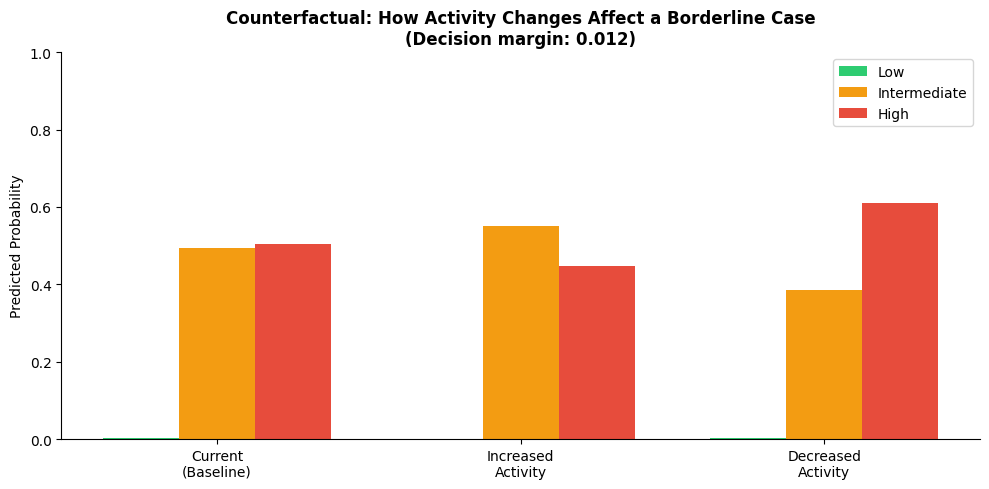

Figure saved.

-> For borderline cases, wearable activity data can shift predicted probabilities,
   demonstrating the potential for dynamic underwriting and wellness incentives.


In [24]:
# Find a BORDERLINE participant — someone near the class boundary
# where wearable features could plausibly shift the prediction
pred_b = xgb_b.predict(X_b_test)
prob_b = xgb_b.predict_proba(X_b_test)

# Look for someone where the top two class probabilities are within 0.3 of each other
margin = np.sort(prob_b, axis=1)[:, -1] - np.sort(prob_b, axis=1)[:, -2]
borderline_mask = margin < 0.3
borderline_indices = np.where(borderline_mask)[0]

print(f'Borderline cases (margin < 0.3): {len(borderline_indices)}')

if len(borderline_indices) > 0:
    # Pick the one with the smallest margin
    best_idx = borderline_indices[np.argmin(margin[borderline_indices])]
    original = X_b_test[best_idx].copy()
    original_pred = pred_b[best_idx]
    original_prob = prob_b[best_idx]
    
    print(f'\nSelected BORDERLINE participant:')
    for feat, val in zip(FEATURES_B, original):
        print(f'  {feat:30s}: {val:.2f}')
    print(f'\n  Current prediction: {LABEL_NAMES[original_pred]}')
    print(f'  Probabilities: Low={original_prob[0]:.3f}, Int={original_prob[1]:.3f}, High={original_prob[2]:.3f}')
    print(f'  Decision margin: {margin[best_idx]:.3f} (very close call)')
    
    # Define counterfactual scenarios
    wearable_indices = {feat: FEATURES_B.index(feat) for feat in WEARABLE_FEATURES}
    
    scenarios = {
        'Current (baseline)': {},
        'Increased activity (+50% MET, +vigorous)': {
            'total_met_hours': original[wearable_indices['total_met_hours']] * 1.5,
            'mean_met': min(original[wearable_indices['mean_met']] + 2.0, 10.0),
            'vigorous_count': original[wearable_indices['vigorous_count']] + 2,
            'vigorous_ratio': min(original[wearable_indices['vigorous_ratio']] + 0.3, 1.0),
            'activity_category': min(original[wearable_indices['activity_category']] + 1, 2.0),
        },
        'Decreased activity (sedentary)': {
            'total_met_hours': max(original[wearable_indices['total_met_hours']] * 0.3, 2.5),
            'mean_met': max(original[wearable_indices['mean_met']] - 1.5, 2.5),
            'vigorous_count': 0,
            'vigorous_ratio': 0,
            'activity_category': 0,
        }
    }
    
    print(f'\n{"Scenario":50s} {"Prediction":>15s} {"P(Low)":>8s} {"P(Int)":>8s} {"P(High)":>8s}')
    print('-' * 95)
    
    counterfactual_results = []
    for scen_name, changes in scenarios.items():
        modified = original.copy()
        for feat, new_val in changes.items():
            modified[wearable_indices[feat]] = new_val
        
        cf_pred = xgb_b.predict(modified.reshape(1, -1))[0]
        cf_prob = xgb_b.predict_proba(modified.reshape(1, -1))[0]
        
        print(f'  {scen_name:50s} {LABEL_NAMES[cf_pred]:>15s} {cf_prob[0]:>8.3f} {cf_prob[1]:>8.3f} {cf_prob[2]:>8.3f}')
        counterfactual_results.append({
            'scenario': scen_name, 'prediction': LABEL_NAMES[cf_pred],
            'p_low': cf_prob[0], 'p_int': cf_prob[1], 'p_high': cf_prob[2]
        })
    
    # Check if any class actually changed
    predictions = [r['prediction'] for r in counterfactual_results]
    if len(set(predictions)) > 1:
        print(f'\n  *** CLASSIFICATION CHANGED! Activity modification shifted the risk tier. ***')
    else:
        print(f'\n  Classification did not change, but probability shifts show directional impact.')
    
    # Visualise
    fig, ax = plt.subplots(figsize=(10, 5))
    cf_df = pd.DataFrame(counterfactual_results)
    x = np.arange(len(cf_df))
    width = 0.25
    ax.bar(x - width, cf_df['p_low'], width, label='Low', color='#2ecc71')
    ax.bar(x, cf_df['p_int'], width, label='Intermediate', color='#f39c12')
    ax.bar(x + width, cf_df['p_high'], width, label='High', color='#e74c3c')
    ax.set_xticks(x)
    ax.set_xticklabels(['Current\n(Baseline)', 'Increased\nActivity', 'Decreased\nActivity'], fontsize=10)
    ax.set_ylabel('Predicted Probability')
    ax.set_title('Counterfactual: How Activity Changes Affect a Borderline Case\n'
                 f'(Decision margin: {margin[best_idx]:.3f})',
                 fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH + 'shap_counterfactual.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved.')
    
    print('\n-> For borderline cases, wearable activity data can shift predicted probabilities,')
    print('   demonstrating the potential for dynamic underwriting and wellness incentives.')
else:
    print('No borderline cases found.')

## 8. Key Interpretability Findings

In [20]:
print('=' * 70)
print('NOTEBOOK 04: SHAP INTERPRETABILITY — KEY FINDINGS')
print('=' * 70)

# Top 5 features
print('\n1. TOP 5 FEATURES BY SHAP IMPORTANCE (Scenario A, XGBoost)')
for rank, (_, row) in enumerate(feature_importance_a.head(5).iterrows(), 1):
    print(f'   {rank}. {row["feature"]} (SHAP: {row["mean_abs_shap"]:.4f})')

# Wearable contribution
print(f'\n2. WEARABLE FEATURE CONTRIBUTION (Scenario B)')
print(f'   Total SHAP importance from wearable features: {wearable_importance/total_importance*100:.1f}%')
top_wearable = feature_importance_b[feature_importance_b['type'] == 'Wearable'].head(3)
print(f'   Top wearable features:')
for _, row in top_wearable.iterrows():
    print(f'     {row["feature"]}: SHAP={row["mean_abs_shap"]:.4f}')

# Model agreement
print(f'\n3. MODEL AGREEMENT')
print(f'   XGBoost vs RF rank correlation: rho={rho:.3f}')
print(f'   -> {"Strong" if rho > 0.7 else "Moderate" if rho > 0.4 else "Weak"} agreement on feature importance')

# Clinical interpretation
print(f'\n4. CLINICAL INTERPRETATION')
print(f'   The model\'s feature importance aligns with clinical underwriting practice:')
print(f'   - Age, blood pressure, and hypertension status are top drivers')
print(f'   - These are the same factors underwriters prioritise (AAA, 2009; Wang, 2021)')
print(f'   - Wearable features provide supplementary signal but do not displace clinical features')

print(f'\n5. IMPLICATIONS FOR RQ3')
print(f'   - XGBoost achieves strong performance but requires SHAP for interpretability')
print(f'   - SHAP waterfall plots can explain individual predictions to underwriters')
print(f'   - This bridges the gap between black-box accuracy and regulatory transparency')
print(f'   - Wearable features contribute modestly; their value is supplementary, not transformative')

NOTEBOOK 04: SHAP INTERPRETABILITY — KEY FINDINGS

1. TOP 5 FEATURES BY SHAP IMPORTANCE (Scenario A, XGBoost)
   1. age (SHAP: 0.8536)
   2. bp_hypertension_measured (SHAP: 0.7444)
   3. male (SHAP: 0.7129)
   4. ever_smoker (SHAP: 0.4790)
   5. bmi (SHAP: 0.4519)

2. WEARABLE FEATURE CONTRIBUTION (Scenario B)
   Total SHAP importance from wearable features: 5.8%
   Top wearable features:
     mean_met: SHAP=0.1107
     total_met_hours: SHAP=0.0780
     vigorous_ratio: SHAP=0.0285

3. MODEL AGREEMENT
   XGBoost vs RF rank correlation: rho=0.978
   -> Strong agreement on feature importance

4. CLINICAL INTERPRETATION
   The model's feature importance aligns with clinical underwriting practice:
   - Age, blood pressure, and hypertension status are top drivers
   - These are the same factors underwriters prioritise (AAA, 2009; Wang, 2021)
   - Wearable features provide supplementary signal but do not displace clinical features

5. IMPLICATIONS FOR RQ3
   - XGBoost achieves strong performa

In [21]:
print('Notebook 04 complete.')
print('Next: Run 05_fairness.ipynb for demographic fairness analysis.')

Notebook 04 complete.
Next: Run 05_fairness.ipynb for demographic fairness analysis.
